## Module imports

In [29]:
from pathlib import Path
import jax.numpy as np
import matplotlib.pyplot as plt

from gwfast.gwfastGlobals import detectors as det_dict, detPath, MRSUN_SI, MTSUN_SI, uGpc
import gwfast.waveforms as waveforms
from gwfast.detector import Detector
from gwfast.signals import BasicGWSignal, AGNLensedGWSignal
import gwfast.network as network
from gwfast.lensing_utils import \
    get_agn_lensed_parameters, \
    PML_time_delay_magnification, \
    dLGridGlob, zGridGlob, einstein_angle

from pycbc.psd import *
from pycbc.filter import match
from pycbc.types.frequencyseries import FrequencySeries

from tqdm import tqdm

## Normal lens definition

In [ ]:
# Normal lensing (first order effects) definition
# Yes, this needs to be simplified...
def normal_lens(FD_strain, events, freqs, separate=False):
    r_orbit = events['R_orbit']
    lens_mass = events['M_lz']
    luminosity_distance = events["dL"]
    y_src = events["src_pos"]
    d_LS = r_orbit * np.sqrt(1 - y_src**2)  # R_Sch
    _y_src = y_src * r_orbit  # R_Sch

    # Schwarschild radius
    # A small, but necessary assumption, that the lens is at dL
    z = np.interp(luminosity_distance, dLGridGlob, zGridGlob)
    lens_mass_src = lens_mass / (1 + z)
    R_Sch = 2 * lens_mass_src * MRSUN_SI  # m
    delta = R_Sch / uGpc

    beta = _y_src / luminosity_distance * delta  # Radian
    ang_D_S = luminosity_distance

    ang_D_L = ang_D_S / (1 + d_LS * delta)  # Gpc
    theta_E = einstein_angle(lens_mass_src, ang_D_L, ang_D_S)  # Radian
    time_delay, mag_1, mag_2 = PML_time_delay_magnification(beta_src=beta, theta_E=theta_E)
    time_delay *= lens_mass_src * MTSUN_SI  
    time_delay_phase_shift = np.exp(2j * np.pi * freqs * time_delay)

    image_1 = mag_1 * FD_strain
    image_2 = mag_2 * FD_strain * time_delay_phase_shift
    if separate:
        return image_1, image_2
    else:
        return image_1 + image_2

## Detector setup

In [3]:
# Set up detectors
H1 = Detector('H1', **det_dict['H1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
L1 = Detector('L1', **det_dict['L1'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/AplusDesign.txt')
V1 = Detector('V1', **det_dict['Virgo'],
              noise_curve_path=Path(detPath)/'observing_scenarios_paper/avirgo_O5low_NEW.txt')

wf_model = waveforms.IMRPhenomD()

H1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_AGN = AGNLensedGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_AGN = network.DetNet({'H1': H1_AGN, 'L1': L1_AGN, 'V1': V1_AGN})

H1_BBH = BasicGWSignal(wf_model=wf_model, detector=H1, fmin=10)
L1_BBH = BasicGWSignal(wf_model=wf_model, detector=L1, fmin=10)
V1_BBH = BasicGWSignal(wf_model=wf_model, detector=V1, fmin=10)
HLV_BBH = network.DetNet({'H1': H1_BBH, 'L1': L1_BBH, 'V1': V1_BBH})

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device count: 1
Jax device count: 1
Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Warning! Some of the input parameters will likely yield waveforms with signal length longer than the maximum duration resolved by the frequencies.
Signal length: nan, Maximum duration: 0.25140763427009916.

Initializing jax...
Jax local device cou

## Parameter injection

In [ ]:
# Define a benchmark event
n = 100
shape = (n, n)
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 'dL':np.full(shape, 0.8), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 'tcoal':np.full(shape, 0), 'phase':np.full(shape, 2), 
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5), 'chi1x':np.full(shape, 0), 'chi2x':np.full(shape, 0), 'chi1y':np.full(shape, 0), 'chi2y':np.full(shape, 0), 
    'LambdaTilde':np.full(shape, 0), 'deltaLambda':np.full(shape, 0), 'ecc':np.full(shape, 0), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.5)
}
events = {key: val.astype(np.float64) for key, val in events.items()}

# Waveform metadata
sampling_frequency = 1024.  # Hz
minimum_frequency = 10.  # Hz
maximum_frequency = sampling_frequency / 2
N_freq_bins = 1000

# Make frequency grid
minimum_frequency_array = np.full(shape, minimum_frequency)
maximum_frequency_array = np.full(shape, maximum_frequency)
freq_grid = np.geomspace(minimum_frequency_array, maximum_frequency_array, N_freq_bins)

# Interpolate PSD
freq_array = np.geomspace(minimum_frequency, maximum_frequency, N_freq_bins)
psd_interp = np.interp(freq_array, L1.psd_frequencies, L1.psd_array)
psd_interp_grid = np.reshape(np.repeat(psd_interp, n**2), (-1, n, n))

# Sample parameter space
R_orbit_array = np.geomspace(20, 5000, n)
Mc_array = np.linspace(10, 100, n)
M_lz_array = np.geomspace(5e3, 5e6, n)
src_pos_array = np.linspace(0.05, 0.5, n)

# Prepare injections
R_orbit_mesh, Mc_mesh = np.meshgrid(R_orbit_array, Mc_array, indexing='xy')
events_copy_1 = events.copy()
events_copy_1['R_orbit'] = R_orbit_mesh
events_copy_1['Mc'] = Mc_mesh

R_orbit_mesh, M_lz_mesh = np.meshgrid(R_orbit_array, M_lz_array, indexing='xy')
events_copy_2 = events.copy()
events_copy_2['R_orbit'] = R_orbit_mesh
events_copy_2['M_lz'] = M_lz_mesh

R_orbit_mesh, src_pos_mesh = np.meshgrid(R_orbit_array, src_pos_array, indexing='xy')
events_copy_3 = events.copy()
events_copy_3['R_orbit'] = R_orbit_mesh
events_copy_3['src_pos'] = src_pos_mesh

# Generate strains from L1
FD_strain_unlensed_1 = L1_BBH.GWstrain(freq_grid, events_copy_1)
FD_strain_lensed_1 = L1_AGN.GWstrain(freq_grid, events_copy_1)

FD_strain_unlensed_2 = L1_BBH.GWstrain(freq_grid, events_copy_2)
FD_strain_lensed_2 = L1_AGN.GWstrain(freq_grid, events_copy_2)

FD_strain_unlensed_3 = L1_BBH.GWstrain(freq_grid, events_copy_3)
FD_strain_lensed_3 = L1_AGN.GWstrain(freq_grid, events_copy_3)

# Combine unlensed waveforms to make normal lensed waveforms
FD_strain_normal_lensed_1 = normal_lens(FD_strain_unlensed_1, events_copy_1, freq_grid)
FD_strain_normal_lensed_2 = normal_lens(FD_strain_unlensed_2, events_copy_2, freq_grid)
FD_strain_normal_lensed_3 = normal_lens(FD_strain_unlensed_3, events_copy_3, freq_grid)

## Check waveform

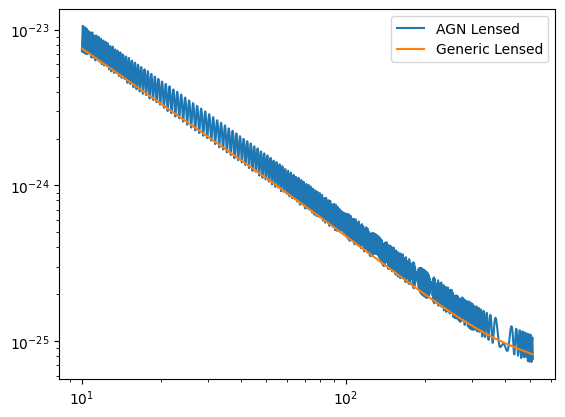

In [13]:
plt.loglog(freq_grid[:,0,0], np.abs(FD_strain_lensed_1[:,0,0]), label='AGN Lensed')
plt.loglog(freq_grid[:,0,0], np.abs(FD_strain_normal_lensed_1[:,0,0]), label='Generic Lensed')
plt.legend()

## Compute match

In [31]:
match_1_array = np.zeros((n, n))
match_2_array = np.zeros((n, n))
match_3_array = np.zeros((n, n))

for i in tqdm(range(n)):
    for j in range(n):
        freq_array_temp = freq_grid[:, i, j]
        AGN_temp_1 = FD_strain_lensed_1[:, i, j]
        AGN_temp_2 = FD_strain_lensed_2[:, i, j]
        AGN_temp_3 = FD_strain_lensed_3[:, i, j]

        normal_temp_1 = FD_strain_normal_lensed_1[:, i, j]
        normal_temp_2 = FD_strain_normal_lensed_2[:, i, j]
        normal_temp_3 = FD_strain_normal_lensed_3[:, i, j]

        psd_FS = FrequencySeries(np.asarray(psd_interp), delta_f=freq_array_temp[1]-freq_array_temp[0], epoch=0)
        normal_lensed_FS_1 = FrequencySeries(np.asarray(normal_temp_1), delta_f=freq_array_temp[1]-freq_array_temp[0], epoch=0)
        normal_lensed_FS_2 = FrequencySeries(np.asarray(normal_temp_2), delta_f=freq_array_temp[1]-freq_array_temp[0], epoch=0)
        normal_lensed_FS_3 = FrequencySeries(np.asarray(normal_temp_3), delta_f=freq_array_temp[1]-freq_array_temp[0], epoch=0)
        AGN_lensed_FS_1 = FrequencySeries(np.asarray(AGN_temp_1), delta_f=freq_array_temp[1]-freq_array_temp[0], epoch=0)
        AGN_lensed_FS_2 = FrequencySeries(np.asarray(AGN_temp_2), delta_f=freq_array_temp[1]-freq_array_temp[0], epoch=0)
        AGN_lensed_FS_3 = FrequencySeries(np.asarray(AGN_temp_3), delta_f=freq_array_temp[1]-freq_array_temp[0], epoch=0)

        # Compute match
        match_1, _ = match(normal_lensed_FS_1, 
                        AGN_lensed_FS_1, 
                        psd=psd_FS, 
                        low_frequency_cutoff=minimum_frequency)
        match_2, _ = match(AGN_lensed_FS_2, 
                        normal_lensed_FS_2, 
                        psd=psd_FS, 
                        low_frequency_cutoff=minimum_frequency)
        match_3, _ = match(AGN_lensed_FS_3, 
                        normal_lensed_FS_3, 
                        psd=psd_FS, 
                        low_frequency_cutoff=minimum_frequency)
        
        match_1_array[i, j] = match_1
        match_2_array[i, j] = match_2
        match_3_array[i, j] = match_3

100%|██████████| 100/100 [07:31<00:00,  4.51s/it]


## Plot match wrt $R_{\mathrm{orbit}}$, $\mathcal{M}$, $M_{\mathrm{Lz}}$, $y\equiv \bar y/R_{\mathrm{orbit}}$

Text(0, 0.5, '$y$')

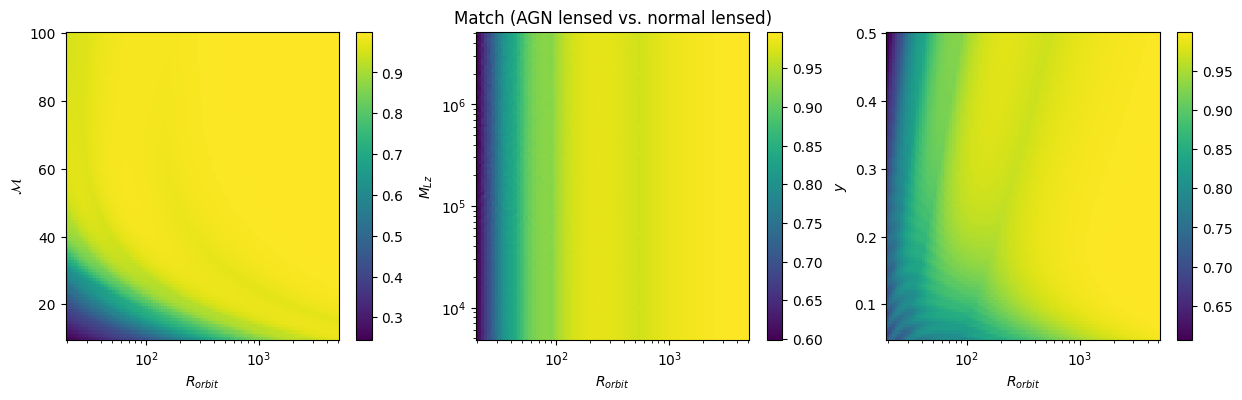

In [ ]:
# Plot
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

ax = axs[0]
im = ax.pcolormesh(R_orbit_array, Mc_array, match_1_array)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_xlabel(r'$R_{orbit}$')
ax.set_ylabel(r'$\cal M$')

ax = axs[1]
im = ax.pcolormesh(R_orbit_array, M_lz_array, match_2_array)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title('Match (AGN lensed vs. normal lensed)')
ax.set_xlabel(r'$R_{orbit}$')
ax.set_ylabel(r'$M_{Lz}$')

ax = axs[2]
im = ax.pcolormesh(R_orbit_array, src_pos_array, match_3_array)
fig.colorbar(im)
ax.set_xscale('log')
ax.set_xlabel(r'$R_{orbit}$')
ax.set_ylabel(r'$y$')